Dataset Preview:

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape: (20640, 9)

Model Performance:

               Model    RMSE  R2 Score
0  Linear Regression  0.7456    0.5758
1   Ridge Regression  0.7456    0.5758
2      Decision Tree  0.7242    0.5997

Best Model: Decision Tree


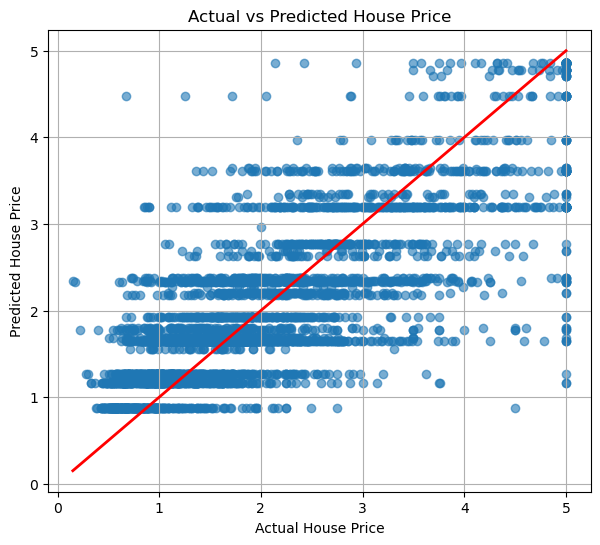

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Load the California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Dataset Preview:\n")
print(df.head())

print("\nDataset Shape:", df.shape)

# Split the dataset into features and target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Scale the features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Create training and testing datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Define the regression models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    )
}

performance = []

# Train each model and evaluate its performance
for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    performance.append({
        "Model": name,
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

# Display comparison table
results = pd.DataFrame(performance)

print("\nModel Performance:\n")
print(results)

# Select the model with the highest R² score
best_model_name = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]

print("\nBest Model:", best_model_name)

best_model = models[best_model_name]

# Predict using the best model
predictions = best_model.predict(X_test)

# Plot Actual vs Predicted values
plt.figure(figsize=(7, 6))

plt.scatter(y_test, predictions, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")
plt.grid(True)

plt.show()